**Student Name : Manisha Purushothaman**

**Student ID : 4108IDJE**
# Skill Extraction and Job Role Classification from LinkedIn Job Postings Using NLP and Transformer Models

## Project Objective

This project uses the LinkedIn Job Postings 2023–2024 dataset for an NLP project on skill extraction and job role classification. The project cleans and anonymises job descriptions, creates rule-based job role labels, extracts skills using an ESCO-style skill dictionary, and produces summary reports and charts for further modelling.

## Research Question

How effectively can traditional machine learning and transformer-based NLP models classify job roles and extract important skills from LinkedIn job descriptions?

## Dataset

The dataset used in this project is the LinkedIn Job Postings 2023–2024 dataset from Kaggle. It contains job titles, descriptions, locations, salary-related fields, work type and company-related information. The raw dataset is cleaned before analysis because job descriptions may contain privacy-risk information such as emails, phone numbers, recruiter contact details and URLs.

Dataset: https://www.kaggle.com/datasets/arshkon/linkedin-job-postings?resource=download

In [16]:
# Install required packages
!pip install -q kagglehub[pandas-datasets] pandas numpy matplotlib seaborn

In [17]:
#import required libraries
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import warnings
import os # Import os module to list directory contents
warnings.filterwarnings('ignore')

print("Loading dataset from Kaggle...")
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "arshkon/linkedin-job-postings",
    "postings.csv"
)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loading dataset from Kaggle...
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Loaded: 123,849 rows × 31 columns


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [18]:
import os
import pandas as pd

# Create reports folder
os.makedirs("reports", exist_ok=True)
#── 2.1 Basic info
print("=" * 55)
print("DATASET AUDIT REPORT")
print("=" * 55)

print(f"Shape          : {df.shape}")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()

# ── 2.2 Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

audit = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
})

audit_missing = audit[audit["missing_count"] > 0].sort_values(
    "missing_%",
    ascending=False
)

display(audit_missing)

# Save missing value report
audit_missing.to_csv("reports/missing_values_report.csv")

print("Saved → reports/missing_values_report.csv")

DATASET AUDIT REPORT
Shape          : (123849, 31)
Memory usage   : 973.2 MB



,missing_count,missing_%
closed_time,122776,99.13
skills_desc,121410,98.03
med_salary,117569,94.93
remote_allowed,108603,87.69
applies,100529,81.17
min_salary,94056,75.94
max_salary,94056,75.94
pay_period,87776,70.87
compensation_type,87776,70.87
normalized_salary,87776,70.87


Saved → reports/missing_values_report.csv


In [19]:
# ── 2.3 Column dtypes overview
print("COLUMN DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\nKey columns sample:")

key_cols = [
    c for c in [
        "title",
        "description",
        "location",
        "max_salary",
        "formatted_work_type",
        "formatted_experience_level"
    ]
    if c in df.columns
]

print(df[key_cols].head(3).to_string())

COLUMN DATA TYPES
job_id                          int64
company_name                   object
title                          object
description                    object
max_salary                    float64
pay_period                     object
location                       object
company_id                    float64
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type            object
applies                       float64
original_listed_time          float64
remote_allowed                float64
job_posting_url                object
application_url                object
application_type               object
expiry                        float64
closed_time                   float64
formatted_experience_level     object
skills_desc                    object
listed_time                   float64
posting_domain                 object
sponsored                       int64
work_type                      o

In [20]:
# ── 2.4 Handle missing values based on column purpose

import numpy as np
import pandas as pd

# Make a copy so original df is unchanged
clean_df = df.copy()

print("Original shape:", clean_df.shape)

# 1. Drop columns that are risky, weak, or not useful for this NLP project
drop_cols = [
    "application_url",      # privacy risk
    "job_posting_url",      # traceable URL
    "job_id",               # trace identifier
    "company_id",           # trace identifier
    "fips",                 # not needed for NLP
    "closed_time",          # very high missing values
    "sponsored",            # zero variance
    "skills_desc",          # very high missing values
    "med_salary"            # very high missing values
]

drop_cols_existing = [col for col in drop_cols if col in clean_df.columns]
clean_df = clean_df.drop(columns=drop_cols_existing)

print("Dropped columns:", drop_cols_existing)
print("Shape after dropping columns:", clean_df.shape)


# 2. Remove rows where description is missing
if "description" in clean_df.columns:
    clean_df = clean_df.dropna(subset=["description"])

    # Remove very short descriptions because they are not useful for NLP
    clean_df = clean_df[clean_df["description"].astype(str).str.len() >= 50]

print("Shape after removing missing/short descriptions:", clean_df.shape)


# 3. Fill missing categorical/text metadata with 'Unknown'
categorical_fill_cols = [
    "posting_domain",
    "formatted_experience_level",
    "company_name",
    "zip_code",
    "pay_period",
    "currency",
    "compensation_type"
]

for col in categorical_fill_cols:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna("Unknown")


# 4. Fill missing numeric columns with median
numeric_median_cols = [
    "views",
    "applies",
    "min_salary",
    "max_salary",
    "normalized_salary",
    "remote_allowed"
]

for col in numeric_median_cols:
    if col in clean_df.columns:
        median_value = clean_df[col].median()
        clean_df[col] = clean_df[col].fillna(median_value)


# 5. Check remaining missing values
remaining_missing = clean_df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

if remaining_missing.empty:
    print("No remaining missing values found.")
else:
    print(remaining_missing)

print("\nFinal shape after missing value handling:", clean_df.shape)

Original shape: (123849, 31)
Dropped columns: ['application_url', 'job_posting_url', 'job_id', 'company_id', 'fips', 'closed_time', 'sponsored', 'skills_desc', 'med_salary']
Shape after dropping columns: (123849, 22)
Shape after removing missing/short descriptions: (123782, 22)
No remaining missing values found.

Final shape after missing value handling: (123782, 22)


3. PII Detection & Removal (GDPR Compliance)

In [21]:
import re
import pandas as pd
import os

os.makedirs("reports", exist_ok=True)

# Regex patterns for PII
EMAIL_PATTERN = r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}'
PHONE_PATTERN = r'(\+?\d[\d\s\-().]{7,}\d)'
URL_PATTERN = r'https?://[^\s<>"]+|www\.[^\s<>"]+'
RECRUITER_PATTERN = r'\b(?:contact|reach out to|email|call|apply to)\s+[A-Z][a-z]+\s+[A-Z][a-z]+\b'

def detect_pii(text):
    """Detect emails, phone numbers, URLs and recruiter contact phrases."""
    if not isinstance(text, str):
        return {
            "emails": [],
            "phones": [],
            "urls": [],
            "recruiters": []
        }

    return {
        "emails": re.findall(EMAIL_PATTERN, text),
        "phones": re.findall(PHONE_PATTERN, text),
        "urls": re.findall(URL_PATTERN, text),
        "recruiters": re.findall(RECRUITER_PATTERN, text)
    }

def remove_pii(text):
    """Remove or mask PII from text."""
    if not isinstance(text, str):
        return text

    text = re.sub(EMAIL_PATTERN, "[EMAIL REMOVED]", text)
    text = re.sub(URL_PATTERN, "[URL REMOVED]", text)
    text = re.sub(PHONE_PATTERN, "[PHONE REMOVED]", text)
    text = re.sub(RECRUITER_PATTERN, "[CONTACT REMOVED]", text)

    return text.strip()

# PII audit on full dataset description column
pii_found = df["description"].dropna().apply(detect_pii)

emails_count = pii_found.apply(lambda x: len(x["emails"])).sum()
phones_count = pii_found.apply(lambda x: len(x["phones"])).sum()
urls_count = pii_found.apply(lambda x: len(x["urls"])).sum()
recruiters_count = pii_found.apply(lambda x: len(x["recruiters"])).sum()

pii_summary = pd.DataFrame({
    "PII Type": ["Emails", "Phone numbers", "URLs", "Recruiter contact phrases"],
    "Count Found": [emails_count, phones_count, urls_count, recruiters_count]
})
display(pii_summary)

pii_summary.to_csv("reports/pii_audit_summary.csv", index=False)

print("Saved → reports/pii_audit_summary.csv")
clean_df["description_clean"] = clean_df["description"].apply(remove_pii)

print("PII removed from description column.")

,PII Type,Count Found
0,Emails,18574
1,Phone numbers,20927
2,URLs,29868
3,Recruiter contact phrases,2699


Saved → reports/pii_audit_summary.csv
PII removed from description column.


In [22]:
# ── Apply PII removal to text columns

df_clean = clean_df.copy()

# Create cleaned description column
df_clean["description_clean"] = df_clean["description"].apply(remove_pii)

# Clean only the text columns needed for modelling
TEXT_COLS = [c for c in ["description_clean", "title"] if c in df_clean.columns]

for col in TEXT_COLS:
    print(f"Cleaning column: {col} ...")
    df_clean[col] = df_clean[col].apply(remove_pii)

# Drop rows with missing title or cleaned description
df_clean = df_clean.dropna(subset=["title", "description_clean"])

# Drop full duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean):,} duplicate rows")

# Remove raw description before final save
df_clean = df_clean.drop(columns=["description"], errors="ignore")

print(f"Final shape after cleaning: {df_clean.shape}")

Cleaning column: description_clean ...
Cleaning column: title ...
Removed 304 duplicate rows
Final shape after cleaning: (123478, 22)


In [23]:
import pandas as pd
import os

os.makedirs("reports", exist_ok=True)

cleaning_summary = pd.DataFrame({
    "Cleaning Step": [
        "Original dataset",
        "Risky / weak columns removed",
        "Missing and short descriptions removed",
        "Duplicate rows removed",
        "Final cleaned dataset"
    ],
    "Result": [
        "123,849 rows, 31 columns",
        "9 columns removed",
        "67 rows removed",
        "304 duplicate rows removed",
        f"{df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns"
    ],
    "Reason": [
        "Raw LinkedIn job postings dataset",
        "Privacy risk, traceability, high missing values or low value",
        "Descriptions are required for NLP modelling",
        "Duplicate postings can bias model training",
        "Ready for EDA, skill extraction and modelling"
    ]
})

display(cleaning_summary)

cleaning_summary.to_csv("reports/data_cleaning_summary.csv", index=False)

print("Saved → reports/data_cleaning_summary.csv")

,Cleaning Step,Result,Reason
0,Original dataset,"123,849 rows, 31 columns",Raw LinkedIn job postings dataset
1,Risky / weak columns removed,9 columns removed,"Privacy risk, traceability, high missing value..."
2,Missing and short descriptions removed,67 rows removed,Descriptions are required for NLP modelling
3,Duplicate rows removed,304 duplicate rows removed,Duplicate postings can bias model training
4,Final cleaned dataset,"123,478 rows, 22 columns","Ready for EDA, skill extraction and modelling"


Saved → reports/data_cleaning_summary.csv


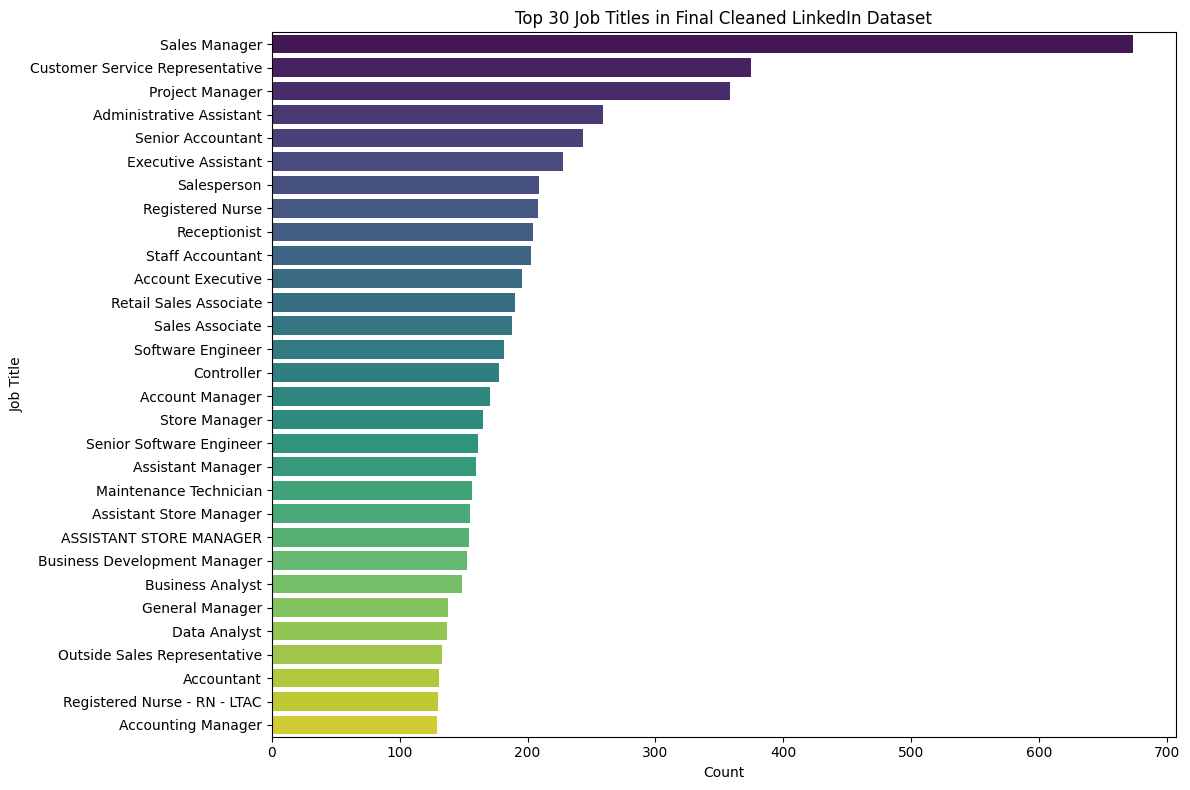

Saved → reports/top_job_titles_cleaned.png


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("reports", exist_ok=True)

top_titles = df_clean["title"].value_counts().head(30)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_titles.values, y=top_titles.index, palette="viridis")
plt.title("Top 30 Job Titles in Final Cleaned LinkedIn Dataset")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.tight_layout()

plt.savefig("reports/top_job_titles_cleaned.png", dpi=150)
plt.show()

print("Saved → reports/top_job_titles_cleaned.png")

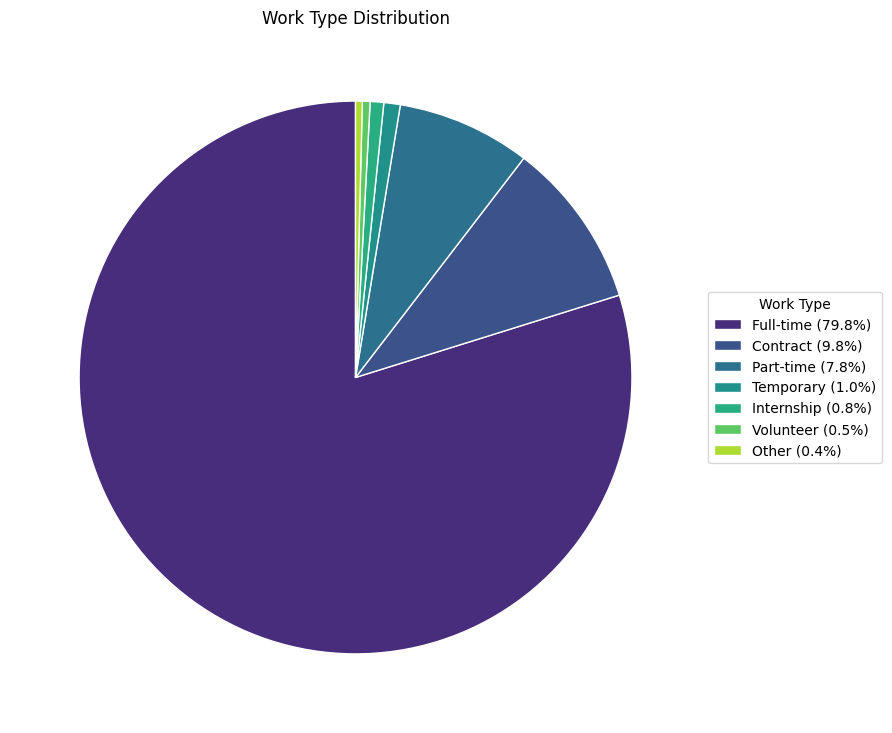

Saved → reports/work_type_distribution.png


In [34]:
# Work type distribution (Pie Chart - percentages in legend only)

work_counts = df_clean["formatted_work_type"].value_counts()
percentages = (work_counts / work_counts.sum() * 100).round(1)

plt.figure(figsize=(9, 9))
colors = sns.color_palette("viridis", len(work_counts))

wedges, _ = plt.pie(work_counts.values,labels=None,startangle=90,colors=colors,wedgeprops={'edgecolor': 'white', 'linewidth': 1})

# Build legend labels with category name + percentage
legend_labels = [f"{cat} ({pct}%)" for cat, pct in zip(work_counts.index, percentages)]

plt.legend(wedges,legend_labels,title="Work Type",loc="center left",bbox_to_anchor=(1, 0, 0.5, 1))

plt.title("Work Type Distribution")
plt.tight_layout()

plt.savefig("reports/work_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved → reports/work_type_distribution.png")

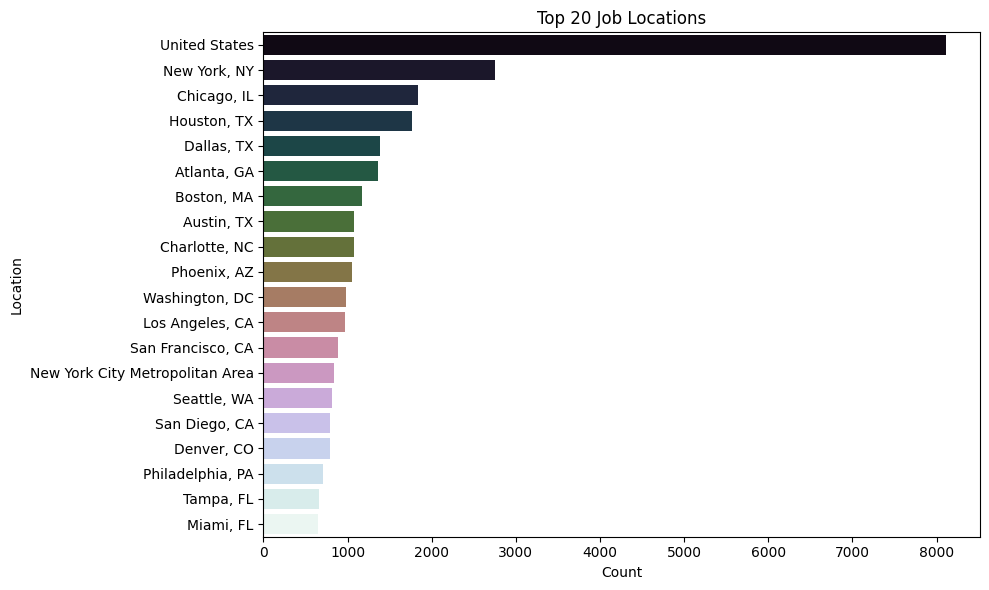

Saved → reports/top_locations.png


In [27]:
# Top 20 job locations

top_locations = df_clean["location"].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette="cubehelix")
plt.title("Top 20 Job Locations")
plt.xlabel("Count")
plt.ylabel("Location")
plt.tight_layout()

plt.savefig("reports/top_locations.png", dpi=150)
plt.show()

print("Saved → reports/top_locations.png")

In [28]:
# Salary availability check

salary_cols = ["min_salary", "max_salary", "normalized_salary"]
available_salary_cols = [col for col in salary_cols if col in df_clean.columns]

salary_availability = pd.DataFrame({
    "Column": available_salary_cols,
    "Available Count": [df_clean[col].notna().sum() for col in available_salary_cols],
    "Missing Count": [df_clean[col].isna().sum() for col in available_salary_cols]
})

display(salary_availability)

salary_availability.to_csv("reports/salary_availability.csv", index=False)

print("Saved → reports/salary_availability.csv")

,Column,Available Count,Missing Count
0,min_salary,123478,0
1,max_salary,123478,0
2,normalized_salary,123478,0


Saved → reports/salary_availability.csv


In [29]:
import os

os.makedirs("processed_data", exist_ok=True)

df_clean.to_csv("processed_data/postings_cleaned.csv", index=False)

print("Saved final cleaned dataset → processed_data/postings_cleaned.csv")
print("Final cleaned shape:", df_clean.shape)

Saved final cleaned dataset → processed_data/postings_cleaned.csv
Final cleaned shape: (123478, 22)
